In [4]:
from pathlib import Path
import sys

# Project root
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [5]:
%load_ext autoreload
%autoreload 2

## Business Question

**What drives checkout abandonment, and how can we identify high-intent users before they leave?**

In [14]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

import matplotlib.pyplot as plt

from src.services import (
    load_funnel,
    load_checkout_abandonment,
    load_purchase_prediction
)

plt.style.use("default")
pd.set_option("display.max_columns", None)

In [3]:
df_funnel = load_funnel()
df_checkout = load_checkout_abandonment()
df_prediction = load_purchase_prediction()

display(df_funnel.head())
display(df_checkout.head())
display(df_prediction.head())

,stage,sessions,overall_conversion_rate,stage_conversion_rate,stage_dropoff_rate
0,Page View,349545,100.00,100.00,0.00
1,View Item,76290,21.83,21.83,78.17
2,Add to Cart,15132,4.33,19.83,80.17
3,Begin Checkout,11088,3.17,73.28,26.72
4,Purchase,4845,1.39,43.70,56.30


,ga_session_id,user_pseudo_id,purchased,checkout_abandoned,session_start,session_end,session_duration_sec,total_events,total_engagement_time,pageviews,...,add_to_cart,begin_checkout,add_shipping_info,add_payment_info,device_category,operating_system,country,session_source,session_medium,session_campaign
0,7264974706,25965924.6537966595,False,True,2021-01-18 10:20:11.673779+00:00,2021-01-18 10:59:51.582504+00:00,2379,34,121378,9,...,1,6,2,1,mobile,Web,United States,(data deleted),(data deleted),(data deleted)
1,4352613376,6273742.7608658637,True,False,2020-11-25 03:44:55.322990+00:00,2020-11-25 04:20:03.131129+00:00,2107,44,320472,16,...,0,1,1,1,desktop,Web,United States,(data deleted),(data deleted),(data deleted)
2,8224937500,3807582.7673594726,True,False,2020-11-11 08:45:13.989092+00:00,2020-11-11 09:01:14.270508+00:00,960,55,822086,19,...,0,1,1,2,desktop,Web,United States,(data deleted),(data deleted),(data deleted)
3,2254232357,6574805.3436225086,True,False,2020-12-18 05:28:12.821910+00:00,2020-12-18 05:44:15.308835+00:00,962,63,471058,16,...,0,9,3,1,desktop,Web,United States,(data deleted),(data deleted),(data deleted)
4,8319721556,62058490.2605722964,True,False,2020-12-04 16:27:30.499229+00:00,2020-12-05 04:07:43.620360+00:00,42013,91,560564,24,...,4,6,3,5,desktop,Web,China,(data deleted),(data deleted),(data deleted)


,session_duration_sec,total_events,total_engagement_time,pageviews,unique_pages,item_views,searches,add_to_cart,begin_checkout,add_shipping_info,add_payment_info,device_category,operating_system,country,session_source,session_medium,session_campaign,purchased
0,33,15,22006,3,4,1,0,1,2,1,0,mobile,Web,United States,NaN,NaN,NaN,False
1,40,16,21801,3,4,1,0,2,2,1,0,mobile,Web,Taiwan,NaN,NaN,NaN,False
2,40,19,15856,6,4,0,0,0,2,1,0,mobile,Android,United States,NaN,NaN,NaN,False
3,1300,171,1080301,48,18,17,0,6,12,6,3,desktop,Web,United States,NaN,NaN,NaN,True
4,66,16,60679,4,5,1,0,0,1,1,0,desktop,Web,United States,(data deleted),(data deleted),(data deleted),False


## 1. Funnel Analysis

,stage,sessions,overall_conversion_rate,stage_conversion_rate,stage_dropoff_rate
0,Page View,349545,100.00,100.00,0.00
1,View Item,76290,21.83,21.83,78.17
2,Add to Cart,15132,4.33,19.83,80.17
3,Begin Checkout,11088,3.17,73.28,26.72
4,Purchase,4845,1.39,43.70,56.30


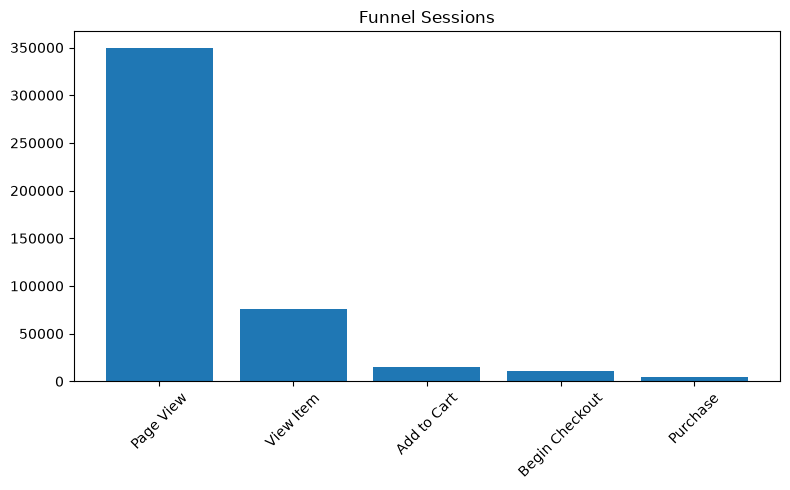

,stage,overall_conversion_rate,stage_conversion_rate,stage_dropoff_rate
0,Page View,100.00,100.00,0.00
1,View Item,21.83,21.83,78.17
2,Add to Cart,4.33,19.83,80.17
3,Begin Checkout,3.17,73.28,26.72
4,Purchase,1.39,43.70,56.30


In [7]:
display(df_funnel)

plt.figure(figsize=(8,5))
plt.bar(df_funnel["stage"], df_funnel["sessions"])
plt.xticks(rotation=45)
plt.title("Funnel Sessions")
plt.tight_layout()
plt.show()

display(
    df_funnel[
        [
            "stage",
            "overall_conversion_rate",
            "stage_conversion_rate",
            "stage_dropoff_rate"
        ]
    ]
)


## 2. Checkout Abandonment Analysis

In [8]:
behavior_cols = [
    "session_duration_sec",
    "total_events",
    "total_engagement_time",
    "pageviews",
    "unique_pages",
    "item_views",
    "searches"
]

summary = (
    df_checkout
    .groupby("purchased")[behavior_cols]
    .mean()
    .round(2)
)

display(summary)

,session_duration_sec,total_events,total_engagement_time,pageviews,unique_pages,item_views,searches
purchased,,,,,,,
False,2893.19,103.33,526353.5,35.26,25.52,14.79,0.59
True,3117.05,108.05,874194.36,31.18,16.16,13.47,0.37


<Figure size 600x400 with 0 Axes>

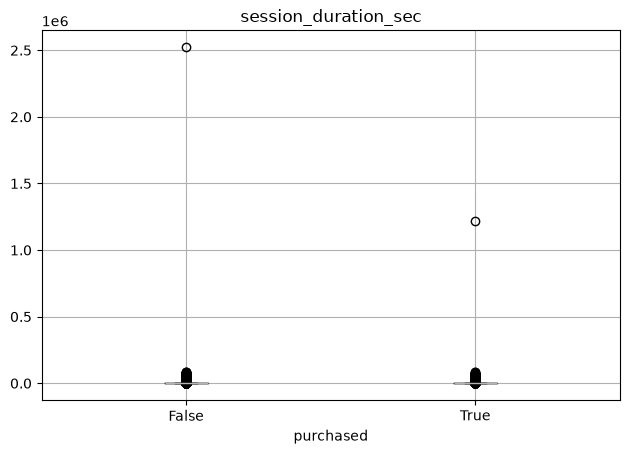

<Figure size 600x400 with 0 Axes>

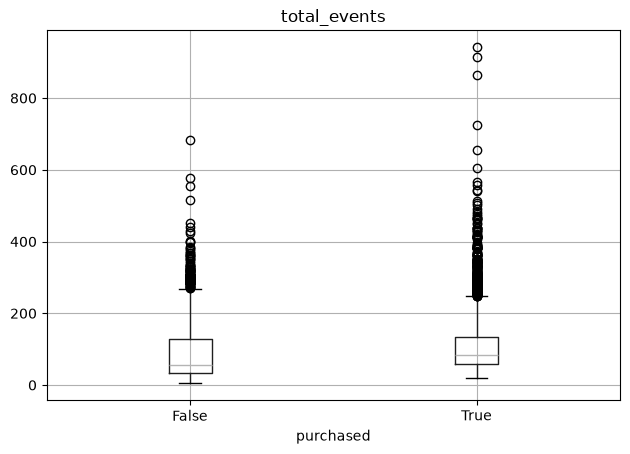

<Figure size 600x400 with 0 Axes>

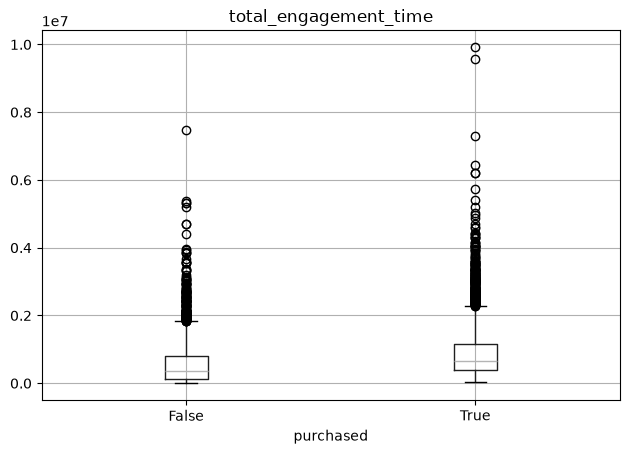

<Figure size 600x400 with 0 Axes>

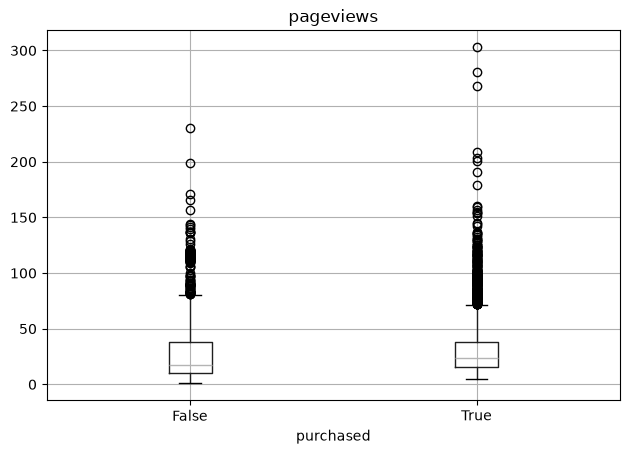

<Figure size 600x400 with 0 Axes>

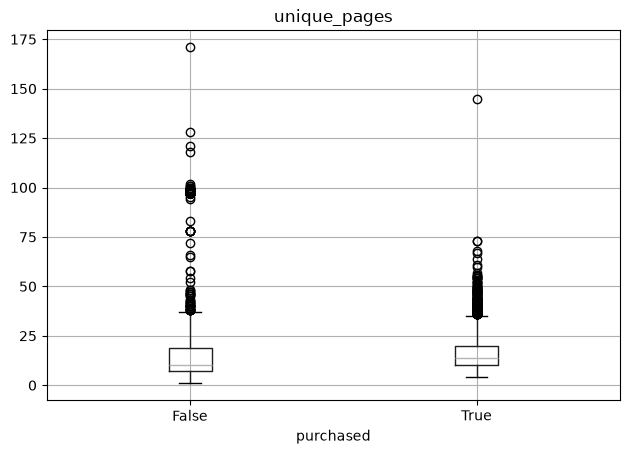

<Figure size 600x400 with 0 Axes>

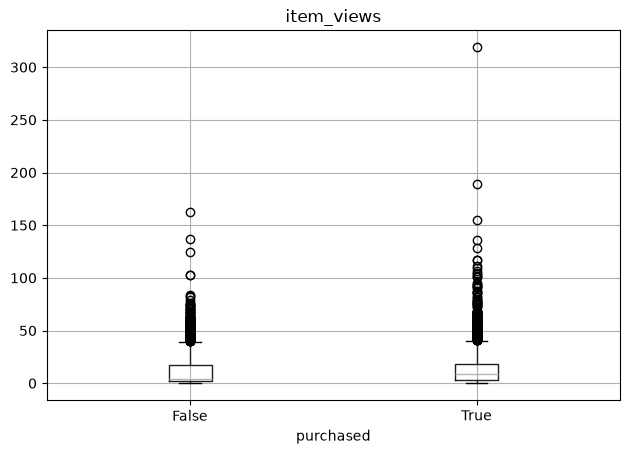

<Figure size 600x400 with 0 Axes>

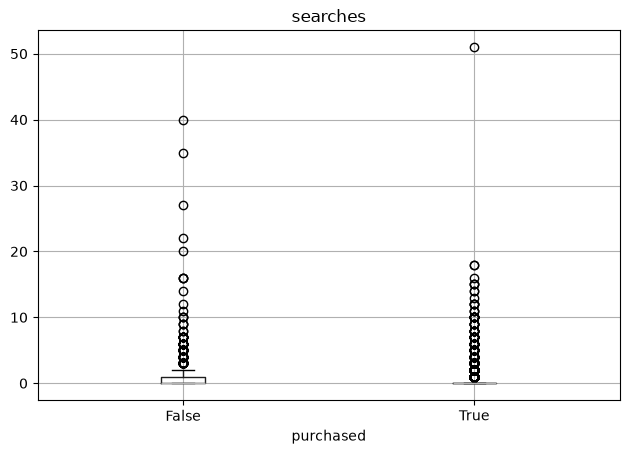

In [9]:
for col in behavior_cols:
    plt.figure(figsize=(6,4))
    df_checkout.boxplot(column=col, by="purchased")
    plt.title(col)
    plt.suptitle("")
    plt.tight_layout()
    plt.show()


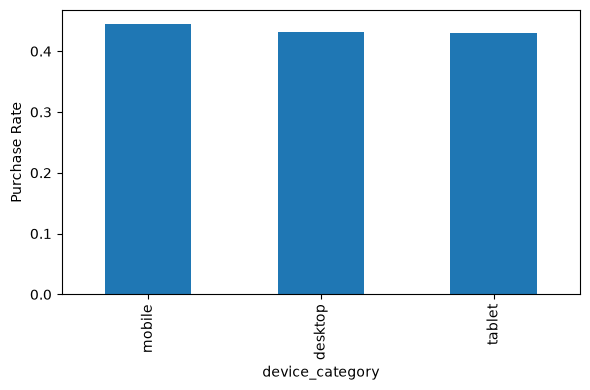

In [10]:
device = (
    df_checkout
    .groupby("device_category")["purchased"]
    .mean()
    .sort_values(ascending=False)
)

device.plot(kind="bar", figsize=(6,4))
plt.ylabel("Purchase Rate")
plt.tight_layout()
plt.show()


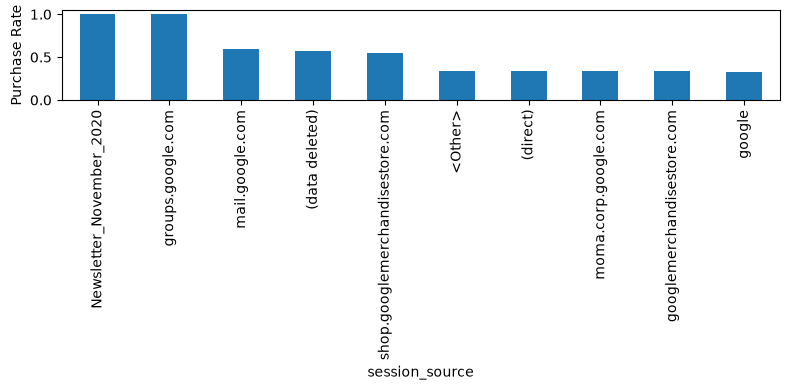

In [11]:
source = (
    df_checkout
    .groupby("session_source")["purchased"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

source.plot(kind="bar", figsize=(8,4))
plt.ylabel("Purchase Rate")
plt.tight_layout()
plt.show()

## 3. User Behaviour Analysis

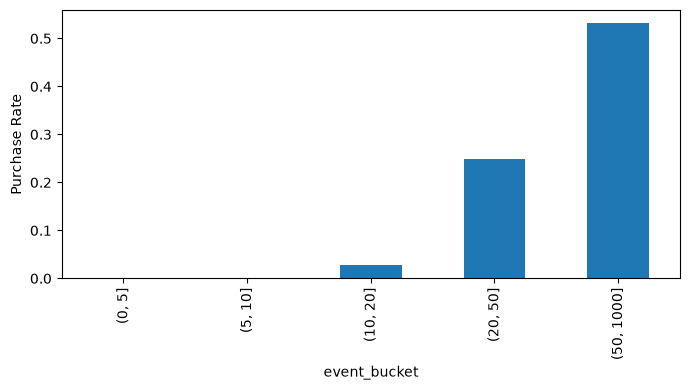

In [12]:
purchase_rate = (
    pd.cut(
        df_checkout["total_events"],
        bins=[0,5,10,20,50,1000]
    )
)

tmp = (
    df_checkout
    .assign(event_bucket=purchase_rate)
    .groupby("event_bucket")["purchased"]
    .mean()
)

tmp.plot(kind="bar", figsize=(7,4))
plt.ylabel("Purchase Rate")
plt.tight_layout()
plt.show()

## 4. Correlation Analysis

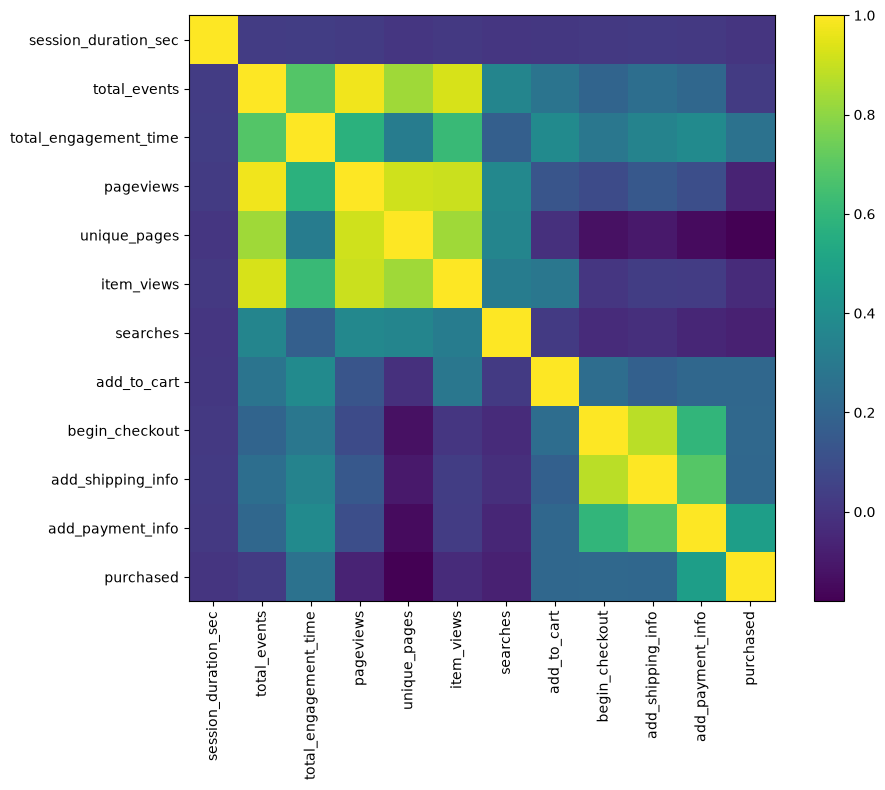

purchased                1.000000
add_payment_info         0.479394
total_engagement_time    0.262502
begin_checkout           0.216961
add_to_cart              0.213192
add_shipping_info        0.212694
total_events             0.025909
session_duration_sec     0.004005
item_views              -0.036782
pageviews               -0.061481
searches                -0.072308
unique_pages            -0.180300
Name: purchased, dtype: float64

In [13]:
numeric = df_prediction.select_dtypes(include="number").copy()
numeric["purchased"] = df_prediction["purchased"].astype(int)

corr = numeric.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.tight_layout()
plt.show()

display(corr["purchased"].sort_values(ascending=False))

## 5. Statistical Validation

In [15]:
purchase = df_checkout[df_checkout["purchased"]]["session_duration_sec"]

abandon = df_checkout[~df_checkout["purchased"]]["session_duration_sec"]

t_stat, p_value = ttest_ind(
    purchase,
    abandon,
    equal_var=False
)

print(t_stat)
print(p_value)

0.44908614927118223
0.6533789267973003


In [16]:
features = [
    "session_duration_sec",
    "total_events",
    "total_engagement_time",
    "pageviews",
    "unique_pages",
    "item_views",
    "searches"
]

results = []

for feature in features:

    purchase = df_checkout[df_checkout["purchased"]][feature]

    abandon = df_checkout[~df_checkout["purchased"]][feature]

    t_stat, p = ttest_ind(
        purchase,
        abandon,
        equal_var=False
    )

    results.append({
        "Feature": feature,
        "Purchase Mean": purchase.mean(),
        "Abandon Mean": abandon.mean(),
        "t-statistic": t_stat,
        "p-value": p
    })

results = pd.DataFrame(results)

results

,Feature,Purchase Mean,Abandon Mean,t-statistic,p-value
0,session_duration_sec,3117.052251,2893.192283,0.449086,6.533789e-01
1,total_events,108.045023,103.332853,2.815595,4.877291e-03
2,total_engagement_time,874194.361008,526353.500801,27.465572,4.438382e-159
3,pageviews,31.184634,35.259046,-6.877768,6.425147e-12
4,unique_pages,16.156753,25.522895,-21.585230,3.338949e-100
5,item_views,13.465717,14.791386,-3.985215,6.785121e-05
6,searches,0.374226,0.585335,-7.538883,5.157517e-14


In [17]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df_checkout["device_category"],
    df_checkout["purchased"]
)

chi2, p, dof, expected = chi2_contingency(table)

print(chi2)
print(p)

2.3432429451338104
0.30986409756835087


In [18]:
from scipy.stats import pointbiserialr

corr, p = pointbiserialr(
    df_prediction["purchased"].astype(int),
    df_prediction["session_duration_sec"]
)

print(corr)
print(p)

0.004005367317592717
0.6732311502421758


In [19]:
features = [
    "session_duration_sec",
    "total_events",
    "total_engagement_time",
    "pageviews",
    "unique_pages",
    "item_views",
    "searches",
    "add_to_cart",
    "begin_checkout",
    "add_shipping_info",
    "add_payment_info"
]

results = []

for feature in features:

    corr, p = pointbiserialr(
        df_prediction["purchased"].astype(int),
        df_prediction[feature]
    )

    results.append({
        "Feature": feature,
        "Correlation": corr,
        "P-value": p
    })

corr_df = (
    pd.DataFrame(results)
    .sort_values(
        "Correlation",
        ascending=False
    )
)

corr_df

,Feature,Correlation,P-value
10,add_payment_info,0.479394,0.000000e+00
2,total_engagement_time,0.262502,3.870631e-174
8,begin_checkout,0.216961,2.965823e-118
7,add_to_cart,0.213192,3.730477e-114
9,add_shipping_info,0.212694,1.282465e-113
1,total_events,0.025909,6.364825e-03
0,session_duration_sec,0.004005,6.732312e-01
5,item_views,-0.036782,1.070537e-04
3,pageviews,-0.061481,9.216287e-11
6,searches,-0.072308,2.475864e-14
